<a href="https://colab.research.google.com/github/AdaGolan/projekt/blob/main/Projekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import bibliotek

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# Wczytanie danych

In [20]:
file_path = "/content/Data.csv"
df = pd.read_csv(file_path, sep=';')

print(df.head())

   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  


In [21]:
#df.info()
#df.shape

df.drop_duplicates(inplace=True) #Usunięcie duplikatów

# Usunięcie zbędnych znaków
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip('_')
        df[col] = df[col].str.strip('-')
        df[col] = df[col].str.strip('/"')
        df[col] = df[col].replace(' ', np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


# Mapowanie miesięcy

In [22]:
month_mapping = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
    "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12
}
if df['month'].dtype == 'object':
  df['month'] = df['month'].map(month_mapping)
  df['month'].fillna(0, inplace=True)
  df['month'] = df['month'].astype(int)
else:
  print("The 'month' column is not of object type.  Check the data.")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   int64 
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(8), object(9)
memory usage: 600.6+ KB


/tmp/ipykernel_16630/3483406238.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['month'].fillna(0, inplace=True)


# Sprawdzenie braków

In [23]:
df.isnull().sum()
# Nie ma braków

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


# Analiza outlierów

In [24]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['age', 'balance', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous'],
      dtype='object')

In [25]:
df[num_cols].describe()


,age,balance,day,month,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,6.166777,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,2.378380,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,5.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,6.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,8.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,12.000000,3025.000000,50.000000,871.000000,25.000000


In [26]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    print(f"{col}: {len(outliers)} outliers")


age: 38 outliers
balance: 506 outliers
day: 0 outliers
month: 0 outliers
duration: 330 outliers
campaign: 318 outliers
pdays: 816 outliers
previous: 816 outliers


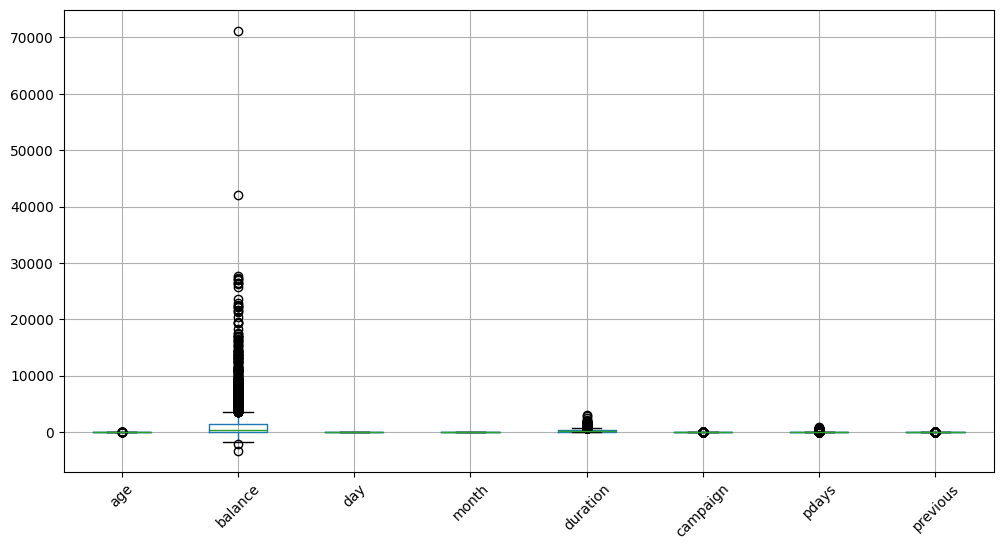

In [27]:
# Wizualizacja
plt.figure(figsize=(12, 6))
df[num_cols].boxplot()
plt.xticks(rotation=45)
plt.show()


# Wnisoki z analizy outlierów:
*   **Kolumna age** - 38 outlierów - Wiek 19–87 to realistyczny zakres. Outliery wynikają z tego, że rozkład wieku nie jest idealnie normalny. - **Nie usuwamy**
*   **Kolumna balance** — 506 outlierów - Saldo konta ma bardzo długi ogon — część klientów ma bardzo wysokie oszczędności, część ujemne saldo. - **Nie usuwamy**
*   **Kolumny day oraz month** - 0 outlierów
*   **Kolumna duration** — 330 outlierów - Czas rozmowy może wynosić od kilku sekund do ponad 3000 sekund. - Model ma przewidzieć, czy klient zapisze się na lokatę, zanim wykonamy rozmowe telefoniczną - czas rozmowy nie jest znany przez rozmową, czyli w momencie predykcji nie wiemy, ile rozmowa będzie trwała **Usuwamy**
*   **Kolumna campaign** — 318 outlierów - Wysokie wartości są rzadkie, ale nie są błędami. - **Nie usuwamy**
*   **Kolumna pdays** — 816 outlierów - pdays = -1 oznacza „nie kontaktowano wcześniej”. To nie jest outlier, tylko kodowana informacja. - **Nie usuwamy**
*   **Kolumna previous** — 816 outlierów - Większość klientów miała 0 poprzednich kontaktów. To nie są outliery — to naturalny rozkład. - **Nie usuwamy**









## Usuwamy kolumnę **duration**

In [28]:
df = df.drop(columns=['duration'])
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   int64 
 11  campaign   4521 non-null   int64 
 12  pdays      4521 non-null   int64 
 13  previous   4521 non-null   int64 
 14  poutcome   4521 non-null   object
 15  y          4521 non-null   object
dtypes: int64(7), object(9)
memory usage: 565.3+ KB


# Kodowanie zmiennych tekstowych

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split

# Kolumny o różnych kategoriach
cat_cols = ['job', 'marital', 'education', 'contact', 'poutcome']

# Kolumny binarne yes/no
bin_cols = ['default', 'housing', 'loan']

# Mapowanie zmiennych binarnych
for col in bin_cols:
    df[col] = df[col].astype(str).str.strip().str.replace('"', '')
    df[col] = df[col].map({'yes': 1, 'no': 0})

# LabelEncoder dla y
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])

# Podział na X, y
X = df.drop('y', axis=1)
y = df['y']

# OneHotEncoder dla kolumn kategorycznych
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ],
    remainder='passthrough'
)

# Transformacja danych
X_encoded = preprocessor.fit_transform(X)

df.info()
#print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   int64 
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   int64 
 7   loan       4521 non-null   int64 
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   int64 
 11  campaign   4521 non-null   int64 
 12  pdays      4521 non-null   int64 
 13  previous   4521 non-null   int64 
 14  poutcome   4521 non-null   object
 15  y          4521 non-null   int64 
dtypes: int64(11), object(5)
memory usage: 565.3+ KB


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# Kolumny z wieloma kateoriami
cat_cols = ['job', 'marital', 'education', 'contact', 'poutcome']

# Podział na X i y
X = df.drop('y', axis=1)
y = df['y']

# OneHotEncoder dla kolumn kategorycznych
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'   # zostawia kolumny numeryczne bez zmian
)

# Transformacja danych
X_encoded = preprocessor.fit_transform(X)

# Jeśli chcesz zobaczyć finalny kształt danych:
print("Shape before encoding:", X.shape)
print("Shape after encoding:", X_encoded.shape)


Shape before encoding: (4521, 15)
Shape after encoding: (4521, 31)


In [31]:
# print(df.head())
# print(X.head())
X_encoded_df = pd.DataFrame(X_encoded)
X_encoded_df.head()
print(X_encoded_df.head())

    0    1    2    3    4    5    6    7    8    9   ...    21   22      23  \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  ...  30.0  0.0  1787.0   
1  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  ...  33.0  0.0  4789.0   
2  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  35.0  0.0  1350.0   
3  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  30.0  0.0  1476.0   
4  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  59.0  0.0     0.0   

    24   25    26    27   28     29   30  
0  0.0  0.0  19.0  10.0  1.0   -1.0  0.0  
1  1.0  1.0  11.0   5.0  1.0  339.0  4.0  
2  1.0  0.0  16.0   4.0  1.0  330.0  1.0  
3  1.0  1.0   3.0   6.0  4.0   -1.0  0.0  
4  1.0  0.0   5.0   5.0  1.0   -1.0  0.0  

[5 rows x 31 columns]
